In [1]:
#Customer Spending Analysis Using RFM
##Importing Required libraries
import pandas as pd
##Loading Datasets
df = pd.read_csv('OnlineRetail.csv',encoding='ISO-8859-1')

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,InvoiceNo,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12-01-2010 08:26,2.55,17850.0,United Kingdom
1,InvoiceNo,71053,WHITE METAL LANTERN,6,12-01-2010 08:26,3.39,17850.0,United Kingdom
2,InvoiceNo,84406B,CREAM CUPID HEARTS COAT HANGER,8,12-01-2010 08:26,2.75,17850.0,United Kingdom
3,InvoiceNo,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12-01-2010 08:26,3.39,17850.0,United Kingdom
4,InvoiceNo,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12-01-2010 08:26,3.39,17850.0,United Kingdom


In [2]:
##understanding data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [3]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [4]:
df.isnull()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
541904,False,False,False,False,False,False,False,False
541905,False,False,False,False,False,False,False,False
541906,False,False,False,False,False,False,False,False
541907,False,False,False,False,False,False,False,False


In [5]:
##Data Cleaning
#removing negative quantities
df=df[df['Quantity']>0]

In [6]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,InvoiceNo,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12-01-2010 08:26,2.55,17850.0,United Kingdom
1,InvoiceNo,71053,WHITE METAL LANTERN,6,12-01-2010 08:26,3.39,17850.0,United Kingdom
2,InvoiceNo,84406B,CREAM CUPID HEARTS COAT HANGER,8,12-01-2010 08:26,2.75,17850.0,United Kingdom
3,InvoiceNo,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12-01-2010 08:26,3.39,17850.0,United Kingdom
4,InvoiceNo,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12-01-2010 08:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12-09-2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12-09-2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12-09-2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12-09-2011 12:50,4.15,12680.0,France


In [7]:
#creating totalprice column
df['TotalPrice']=df['Quantity']*df['UnitPrice']##feature engineering

In [8]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,InvoiceNo,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12-01-2010 08:26,2.55,17850.0,United Kingdom,15.30
1,InvoiceNo,71053,WHITE METAL LANTERN,6,12-01-2010 08:26,3.39,17850.0,United Kingdom,20.34
2,InvoiceNo,84406B,CREAM CUPID HEARTS COAT HANGER,8,12-01-2010 08:26,2.75,17850.0,United Kingdom,22.00
3,InvoiceNo,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12-01-2010 08:26,3.39,17850.0,United Kingdom,20.34
4,InvoiceNo,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12-01-2010 08:26,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12-09-2011 12:50,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12-09-2011 12:50,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12-09-2011 12:50,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12-09-2011 12:50,4.15,12680.0,France,16.60


In [9]:
#removing missing customer ids
df=df.dropna(subset=['CustomerID'])

In [10]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,InvoiceNo,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12-01-2010 08:26,2.55,17850.0,United Kingdom,15.30
1,InvoiceNo,71053,WHITE METAL LANTERN,6,12-01-2010 08:26,3.39,17850.0,United Kingdom,20.34
2,InvoiceNo,84406B,CREAM CUPID HEARTS COAT HANGER,8,12-01-2010 08:26,2.75,17850.0,United Kingdom,22.00
3,InvoiceNo,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12-01-2010 08:26,3.39,17850.0,United Kingdom,20.34
4,InvoiceNo,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12-01-2010 08:26,3.39,17850.0,United Kingdom,20.34


In [11]:
##Exploratory Data Analysis
#calculating total revenue
total_revenue=df['TotalPrice'].sum()
print('Total Revenue:',total_revenue)

Total Revenue: 8911407.904


In [12]:
#grouping top 10 customers
top_customers = df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False).head(10)
print(top_customers)

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194550.79
16446.0    168472.50
14911.0    143825.06
12415.0    124914.53
14156.0    117379.63
17511.0     91062.38
16029.0     81024.84
12346.0     77183.60
Name: TotalPrice, dtype: float64


In [13]:
#grouping top 10 products
top_products=df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
print('Top Products: ',top_products)

Top Products:  Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54415
JUMBO BAG RED RETROSPOT               46181
WHITE HANGING HEART T-LIGHT HOLDER    36725
ASSORTED COLOUR BIRD ORNAMENT         35362
PACK OF 72 RETROSPOT CAKE CASES       33693
POPCORN HOLDER                        30931
RABBIT NIGHT LIGHT                    27202
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64


In [14]:
# grouping countries based on their sales
country_sales = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False)
print(country_sales.head(10))

Country
United Kingdom    7308391.554
Netherlands        285446.340
EIRE               265545.900
Germany            228867.140
France             209024.050
Australia          138521.310
Spain               61577.110
Switzerland         56443.950
Belgium             41196.340
Sweden              38378.330
Name: TotalPrice, dtype: float64


In [15]:
#monthly sales analysis
##this section analyses how sales vary across different months to identify trends and seasonal patterns
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'],errors='coerce')

df['Month'] = df['InvoiceDate'].dt.month

monthly_sales = df.groupby('Month')['TotalPrice'].sum()
print(monthly_sales)

Month
1.0     207634.82
2.0     169578.94
3.0     210683.68
4.0     195675.34
5.0     281587.21
6.0     278196.33
7.0     187633.64
8.0     294118.83
9.0     279665.69
10.0    425948.27
11.0    463738.40
12.0    881026.84
Name: TotalPrice, dtype: float64


In [16]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [17]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Month
0,InvoiceNo,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,12.0
1,InvoiceNo,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12.0
2,InvoiceNo,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,12.0
3,InvoiceNo,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12.0
4,InvoiceNo,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12.0


In [18]:
## RFM (Recency,Frequency,Monetary)Analysis
snapshot_date=df['InvoiceDate'].max()
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'count',
    'TotalPrice': 'sum'
})

rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalPrice': 'Monetary'
}, inplace=True)

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,NaN,1,77183.60
12347.0,1.0,182,4310.00
12348.0,248.0,31,1797.24
12349.0,NaN,73,1757.55
12350.0,309.0,17,334.40


In [19]:
#assigning rfm scores
rfm['R_score'] = pd.qcut(rfm['Recency'].rank(method='first'), 5, labels=[5,4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_score'] = pd.qcut(rfm['Monetary'].rank(method='first'), 5, labels=[1,2,3,4,5])

In [20]:
rfm['RFM_Score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

In [21]:
rfm

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
CustomerID,,,,,,,
12346.0,NaN,1,77183.60,NaN,1,5,NaN
12347.0,1.0,182,4310.00,5,5,5,5.055
12348.0,248.0,31,1797.24,1,3,4,1.034
12349.0,NaN,73,1757.55,NaN,4,4,NaN
12350.0,309.0,17,334.40,1,2,2,1.022
...,...,...,...,...,...,...,...
18280.0,277.0,10,180.60,1,1,1,1.011
18281.0,180.0,7,80.82,2,1,1,2.011
18282.0,7.0,12,178.05,5,1,1,5.011


In [22]:
##customer segmentation
def segment(rfm):
    if rfm['R_score'] == 5 and rfm['F_score']==5 and rfm['M_score']==5:
        return 'Best Customers'
    elif rfm['R_score'] == 5:
        return 'Recent Customers'
    elif rfm['F_score'] == 5:
        return 'Loyal Customers'
    else:
        return 'Others'

In [23]:
rfm['Segment'] = rfm.apply(segment, axis=1)

In [24]:
"""Key Insights
- Majority of customers fall under "Others" category (~70%)
- Only a small percentage are high-value customers (~5%)
- Loyal customers contribute significantly to revenue
- Businesses should focus on retaining best customers"""

'Key Insights\n- Majority of customers fall under "Others" category (~70%)\n- Only a small percentage are high-value customers (~5%)\n- Loyal customers contribute significantly to revenue\n- Businesses should focus on retaining best customers'

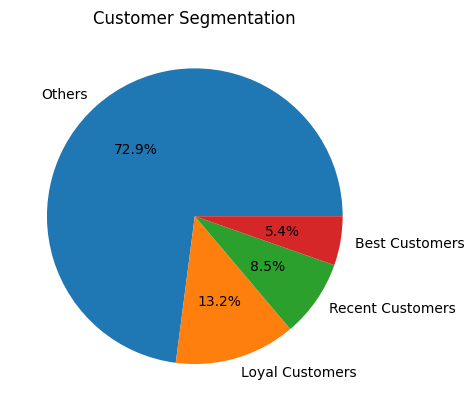

In [25]:
##visualisation
#customer segmentation visualisation
import matplotlib.pyplot as plt

rfm['Segment'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Customer Segmentation")
plt.ylabel('')
plt.show()

In [26]:
## Key Insights:
# Majority of customers fall under "Others" category (~70%)
# Only a small percentage are high-value customers (~5%)
# Loyal customers contribute significantly to revenue
# Businesses should focus on retaining best customers

In [27]:
## conclusion:
#This project demonstrates how customer segmentation using RFM analysis can help businesses understand customer behavior and improve marketing strategies.